In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import boston_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

# Combine train + test (better practice for ML experiments)
X = np.vstack((X_train, X_test))
y = np.hstack((y_train, y_test))

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

In [6]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append((name, mse, r2))

    print(f"{name}")
    print(f"  MSE: {mse:.2f}")
    print(f"  R2 Score: {r2:.2f}")
    print("-"*30)

Linear Regression
  MSE: 46.58
  R2 Score: 0.49
------------------------------
Ridge Regression
  MSE: 46.62
  R2 Score: 0.49
------------------------------
Lasso Regression
  MSE: 48.12
  R2 Score: 0.47
------------------------------
Elastic Net
  MSE: 47.28
  R2 Score: 0.48
------------------------------


In [7]:
results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2 Score"])
print(results_df)

               Model        MSE  R2 Score
0  Linear Regression  46.577131  0.487199
1   Ridge Regression  46.615479  0.486777
2   Lasso Regression  48.118355  0.470231
3        Elastic Net  47.279685  0.479464


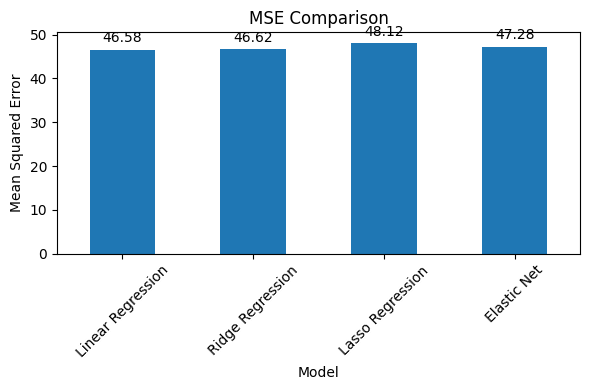

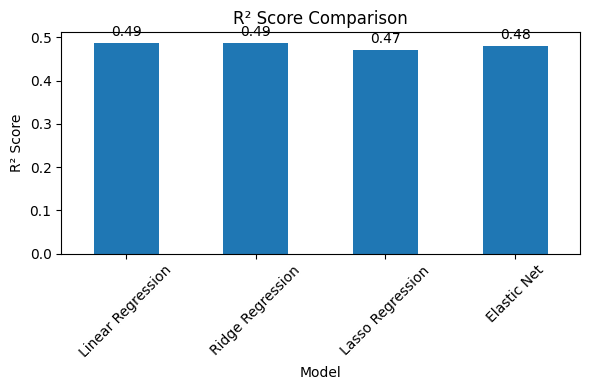

In [10]:
import matplotlib.pyplot as plt

# --- MSE Plot ---
plt.figure(figsize=(6,4))
ax1 = results_df.set_index("Model")["MSE"].plot(kind="bar")

plt.title("MSE Comparison")
plt.ylabel("Mean Squared Error")
plt.xticks(rotation=45)

for container in ax1.containers:
    ax1.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()


# --- R2 Score Plot ---
plt.figure(figsize=(6,4))
ax2 = results_df.set_index("Model")["R2 Score"].plot(kind="bar")

plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=45)

for container in ax2.containers:
    ax2.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()